<a href="https://colab.research.google.com/github/pta20032004/fraud-detection-banking/blob/pre-processing/PTA_Ti%E1%BB%81n_x%E1%BB%AD_l%C3%AD_d%E1%BB%AF_li%E1%BB%87u.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install kagglehub

In [5]:
import kagglehub
import os

path = kagglehub.dataset_download("priyamchoksi/credit-card-transactions-dataset")

print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in dataset:", files)

Using Colab cache for faster access to the 'credit-card-transactions-dataset' dataset.
Path to dataset files: /kaggle/input/credit-card-transactions-dataset
Files in dataset: ['credit_card_transactions.csv']


In [6]:
import pandas as pd
import os

csv_file_path = os.path.join(path, 'credit_card_transactions.csv')

# Load dữ liệu
df = pd.read_csv(csv_file_path)

# Hiển thị 5 dòng đầu tiên
print("5 dòng đầu tiên của bộ dữ liệu:")
display(df.head())


5 dòng đầu tiên của bộ dữ liệu:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [7]:
# Hiển thị danh sách các cột và kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [8]:
# Kiểm tra số lượng dòng và cột
print(f"\nSố lượng dòng: {df.shape[0]}")
print(f"Số lượng cột: {df.shape[1]}")


Số lượng dòng: 1296675
Số lượng cột: 24


In [9]:
# Thống kê giá trị thiếu trong từng cột
print("Số lượng giá trị thiếu trong từng cột:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

print(missing_values)

Số lượng giá trị thiếu trong từng cột:


,0
merch_zipcode,195973


Unnamed: 0                    0
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
dtype: int64


In [10]:
# Tính toán số lượng và tỷ lệ phần trăm nhãn mục tiêu
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': fraud_counts,
    'Percentage (%)': fraud_pct
})

print("Phân tích nhãn mục tiêu (is_fraud):")
display(target_summary)

# Nhận xét về độ mất cân bằng
imbalance_ratio = fraud_counts[0] / fraud_counts[1]
print(f"\nTỷ lệ giữa giao dịch bình thường và gian lận là khoảng {imbalance_ratio:.2f}:1")

Phân tích nhãn mục tiêu (is_fraud):


,Count,Percentage (%)
is_fraud,,
0,1289169,99.421135
1,7506,0.578865



Tỷ lệ giữa giao dịch bình thường và gian lận là khoảng 171.75:1


**1. Cách ly & Capping**

In [11]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive', force_remount=True)

save_path = '/content/drive/MyDrive/fraud detection banking dataset/Raw Data'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 1. Chuyển đổi cột trans_date_trans_time sang datetime để làm chuẩn
df['trans_date_time'] = pd.to_datetime(df['trans_date_trans_time'])

# 2. Lọc dữ liệu
important_cols = ['trans_date_time', 'lat', 'long', 'merch_lat', 'merch_long', 'amt']
df_cleaned = df.dropna(subset=important_cols).copy()

# 3. Sắp xếp theo thời gian thực tế
df_cleaned = df_cleaned.sort_values(by='trans_date_time').reset_index(drop=True)

# 4. Time-based Split
n = len(df_cleaned)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

train_df = df_cleaned.iloc[:train_size].copy()
val_df = df_cleaned.iloc[train_size:train_size + val_size].copy()
test_df = df_cleaned.iloc[train_size + val_size:].copy()

# Lưu dữ liệu vào Drive
train_df.to_csv(os.path.join(save_path, 'train.csv'), index=False)
val_df.to_csv(os.path.join(save_path, 'val.csv'), index=False)
test_df.to_csv(os.path.join(save_path, 'test.csv'), index=False)

# In thông tin kiểm tra với đúng năm 2019-2020
for name, d in zip(['Train', 'Val', 'Test'], [train_df, val_df, test_df]):
    start = d['trans_date_time'].min()
    end = d['trans_date_time'].max()
    print(f"{name} set: {d.shape}, từ {start} đến {end}")

Mounted at /content/drive
Train set: (1037340, 25), từ 2019-01-01 00:00:18 đến 2020-03-06 07:15:17
Val set: (129667, 25), từ 2020-03-06 07:16:43 đến 2020-05-02 11:09:06
Test set: (129668, 25), từ 2020-05-02 11:09:29 đến 2020-06-21 12:13:37


In [12]:
# 4. Xử lý Outlier (Amt) bằng Capping

# Tìm mốc 99th percentile trên tập Train
amt_99th = train_df['amt'].quantile(0.99)
print(f"Mốc 99th percentile của cột 'amt' (Train): {amt_99th:.2f}")

# Thực hiện Capping
train_df['amt'] = train_df['amt'].clip(upper=amt_99th)
val_df['amt'] = val_df['amt'].clip(upper=amt_99th)
test_df['amt'] = test_df['amt'].clip(upper=amt_99th)

# Kiểm tra giá trị tối đa sau khi Capping
print(f"Max 'amt' sau Capping (Train): {train_df['amt'].max():.2f}")
print(f"Max 'amt' sau Capping (Val): {val_df['amt'].max():.2f}")
print(f"Max 'amt' sau Capping (Test): {test_df['amt'].max():.2f}")

Mốc 99th percentile của cột 'amt' (Train): 545.26
Max 'amt' sau Capping (Train): 545.26
Max 'amt' sau Capping (Val): 545.26
Max 'amt' sau Capping (Test): 545.26


Có sự không đồng nhất giữa unix time và  trans_date_trans_time. Chênh lệch nhau 7 years.
Tuy nhiên điều này không quá ảnh hưởng đến kết quả. Sử dụng trans_date_trans_time.

In [13]:
# Chuyển đổi thử nghiệm để so sánh
check_time = pd.DataFrame()
check_time['string_time'] = pd.to_datetime(df['trans_date_trans_time'])
check_time['unix_converted'] = pd.to_datetime(df['unix_time'], unit='s')
check_time['diff_seconds'] = (check_time['string_time'] - check_time['unix_converted']).dt.total_seconds()

print(check_time.head())

          string_time      unix_converted  diff_seconds
0 2019-01-01 00:00:18 2012-01-01 00:00:18   220924800.0
1 2019-01-01 00:00:44 2012-01-01 00:00:44   220924800.0
2 2019-01-01 00:00:51 2012-01-01 00:00:51   220924800.0
3 2019-01-01 00:01:16 2012-01-01 00:01:16   220924800.0
4 2019-01-01 00:03:06 2012-01-01 00:03:06   220924800.0


**2. Feature Engineering**

In [14]:
import numpy as np
import pandas as pd

def calculate_haversine(lat1, lon1, lat2, lon2):
    """Tính khoảng cách Haversine giữa hai điểm tọa độ (đơn vị: km)"""
    r = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * r * np.arcsin(np.sqrt(a))

def apply_feature_engineering(df):
    df = df.copy()

    # --- 1. ĐẶC TRƯNG ĐỘC LẬP ---
    df['distance'] = calculate_haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = (df['trans_date_time'] - df['dob']).dt.days // 365

    hour = df['trans_date_time'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

    day = df['trans_date_time'].dt.dayofweek
    df['day_sin'] = np.sin(2 * np.pi * day / 7)
    df['day_cos'] = np.cos(2 * np.pi * day / 7)

    # --- 2. VELOCITY & IMPOSSIBLE TRAVEL (Fix Leakage) ---
    df = df.sort_values(['cc_num', 'trans_date_time'])
    df['time_diff'] = df.groupby('cc_num')['trans_date_time'].diff().dt.total_seconds()

    # Vận tốc: Đặt NaN cho giao dịch đầu tiên để tránh fillna(1s) gây ảo
    df['travel_speed'] = df['distance'] / (df['time_diff'] / 3600)
    df.loc[df['time_diff'].isna(), 'travel_speed'] = 0

    # Clip vận tốc ở mức 99.9th percentile để tránh outlier cực đoan
    speed_limit = df['travel_speed'].quantile(0.999)
    df['travel_speed'] = df['travel_speed'].clip(upper=speed_limit)

    # Velocity 24h
    df = df.set_index('trans_date_time')
    group = df.groupby('cc_num')['amt']
    df['nb_tx_24h'] = group.rolling('24h', closed='left').count().reset_index(0, drop=True)
    df['avg_amt_24h'] = group.rolling('24h', closed='left').mean().reset_index(0, drop=True)
    df['nb_tx_24h'] = df['nb_tx_24h'].fillna(0)
    df['avg_amt_24h'] = df['avg_amt_24h'].fillna(0)
    df = df.reset_index()

    # --- 3. LOG TRANSFORM ---
    df['amt_log'] = np.log1p(df['amt'])
    return df

# Áp dụng cho TOÀN BỘ df_cleaned trước khi split
print("Đang tính toán Feature Engineering trên toàn bộ dữ liệu...")
df_full_featured = apply_feature_engineering(df_cleaned)

# Thực hiện split lại dựa trên index đã sắp xếp thời gian
df_full_featured = df_full_featured.sort_values('trans_date_time').reset_index(drop=True)
train_df = df_full_featured.iloc[:train_size].copy()
val_df = df_full_featured.iloc[train_size:train_size + val_size].copy()
test_df = df_full_featured.iloc[train_size + val_size:].copy()

print("Đã hoàn thành Fix Leakage và Outlier Speed.")
display(train_df[['trans_date_time', 'cc_num', 'travel_speed', 'nb_tx_24h']].head())

Đang tính toán Feature Engineering trên toàn bộ dữ liệu...
Đã hoàn thành Fix Leakage và Outlier Speed.


,trans_date_time,cc_num,travel_speed,nb_tx_24h
0,2019-01-01 00:00:18,2703186189652095,0.0,0.0
1,2019-01-01 00:00:44,630423337322,0.0,0.0
2,2019-01-01 00:00:51,38859492057661,0.0,0.0
3,2019-01-01 00:01:16,3534093764340240,0.0,0.0
4,2019-01-01 00:03:06,375534208663984,0.0,0.0


**3. Xử lý giá trị thiếu và Lựa chọn đặc trưng**

In [15]:
from sklearn.impute import SimpleImputer

# 1. Danh sách xóa ĐIỀU CHỈNH: Giữ lại 'zip' và 'state' để Encoding ở bước sau
cols_to_drop = [
    'Unnamed: 0', 'first', 'last', 'trans_num', 'trans_date_trans_time',
    'street', 'city', 'dob', 'unix_time',
    'lat', 'long', 'merch_lat', 'merch_long', 'trans_date_time', 'merch_zipcode'
]

# 2. Thực hiện xóa cột trên cả 3 tập
for d in [train_df, val_df, test_df]:
    d.drop(columns=[c for c in cols_to_drop if c in d.columns], inplace=True)

# 3. Chuyển đổi 'zip' sang string vì bản chất là Categorical
for d in [train_df, val_df, test_df]:
    if 'zip' in d.columns:
        d['zip'] = d['zip'].astype(str)

# 4. Phân loại cột để điền khuyết
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.drop('is_fraud')
cat_cols = train_df.select_dtypes(include=['object']).columns

# 5. Điền khuyết cho cột số (Dùng Median)
num_imputer = SimpleImputer(strategy='median')
train_df[num_cols] = num_imputer.fit_transform(train_df[num_cols])
val_df[num_cols] = num_imputer.transform(val_df[num_cols])
test_df[num_cols] = num_imputer.transform(test_df[num_cols])

# 6. Điền khuyết cho cột chữ (Dùng nhãn 'Unknown')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
train_df[cat_cols] = cat_imputer.fit_transform(train_df[cat_cols])
val_df[cat_cols] = cat_imputer.transform(val_df[cat_cols])
test_df[cat_cols] = cat_imputer.transform(test_df[cat_cols])

print("Giai đoạn 3 hoàn tất (Đã điều chỉnh): Đã giữ lại zip/state và điền khuyết.")
print(f"Số lượng cột còn lại: {train_df.shape[1]}")
print("Các cột hiện có:", train_df.columns.tolist())
display(train_df.head())

Giai đoạn 3 hoàn tất (Đã điều chỉnh): Đã giữ lại zip/state và điền khuyết.
Số lượng cột còn lại: 21
Các cột hiện có: ['cc_num', 'merchant', 'category', 'amt', 'gender', 'state', 'zip', 'city_pop', 'job', 'is_fraud', 'distance', 'age', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'time_diff', 'travel_speed', 'nb_tx_24h', 'avg_amt_24h', 'amt_log']


,cc_num,merchant,category,amt,gender,state,zip,city_pop,job,is_fraud,...,age,hour_sin,hour_cos,day_sin,day_cos,time_diff,travel_speed,nb_tx_24h,avg_amt_24h,amt_log
0,2.703186e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,NC,28654,3495.0,"Psychologist, counselling",0,...,30.0,0.0,1.0,0.781831,0.62349,16405.0,0.0,0.0,0.0,1.786747
1,6.304233e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,WA,99160,149.0,Special educational needs teacher,0,...,40.0,0.0,1.0,0.781831,0.62349,16405.0,0.0,0.0,0.0,4.684259
2,3.885949e+13,fraud_Lind-Buckridge,entertainment,220.11,M,ID,83252,4154.0,Nature conservation officer,0,...,56.0,0.0,1.0,0.781831,0.62349,16405.0,0.0,0.0,0.0,5.398660
3,3.534094e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,MT,59632,1939.0,Patent attorney,0,...,52.0,0.0,1.0,0.781831,0.62349,16405.0,0.0,0.0,0.0,3.828641
4,3.755342e+14,fraud_Keeling-Crist,misc_pos,41.96,M,VA,24433,99.0,Dance movement psychotherapist,0,...,32.0,0.0,1.0,0.781831,0.62349,16405.0,0.0,0.0,0.0,3.760269


In [16]:
!pip install category_encoders shap

**4. Encoding & Feature Selection**

In [17]:
from category_encoders import TargetEncoder
from sklearn.model_selection import KFold
import lightgbm as lgb
import shap
import numpy as np
import pandas as pd

# 1. Danh sách các cột High-Cardinality cần Encoding
cat_features = ['merchant', 'category', 'gender', 'job', 'zip', 'state']

# 2. Khởi tạo Target Encoder với Smoothing (m=20)
encoder = TargetEncoder(cols=cat_features, smoothing=20)

# 3. K-Fold Target Encoding cho tập TRAIN (Chống Overfitting)
kf = KFold(n_splits=5, shuffle=False)
train_encoded = train_df.copy()

for col in cat_features:
    train_encoded[f'{col}_target'] = 0.0

print("Đang thực hiện K-Fold Target Encoding trên tập Train...")
for train_idx, val_idx in kf.split(train_df):
    encoder.fit(train_df.iloc[train_idx][cat_features], train_df.iloc[train_idx]['is_fraud'])
    encoded_values = encoder.transform(train_df.iloc[val_idx][cat_features])
    for col in cat_features:
        train_encoded.iloc[val_idx, train_encoded.columns.get_indexer([f'{col}_target'])] = encoded_values[col].values

# 4. Áp dụng cho tập VAL và TEST
encoder.fit(train_df[cat_features], train_df['is_fraud'])
val_encoded = val_df.copy()
test_encoded = test_df.copy()

val_encoded[[f'{c}_target' for c in cat_features]] = encoder.transform(val_df[cat_features])
test_encoded[[f'{c}_target' for c in cat_features]] = encoder.transform(test_df[cat_features])

for d in [train_encoded, val_encoded, test_encoded]:
    d.drop(columns=cat_features, inplace=True)

# --- FEATURE SELECTION VỚI SHAP (Sử dụng GPU) ---
print("Đang thực hiện Feature Selection bằng SHAP values (Sử dụng GPU)...")
X_train = train_encoded.drop(columns=['is_fraud'])
y_train = train_encoded['is_fraud']

# Cấu hình model với GPU
model_fs = lgb.LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1,
    device='gpu'  # Kích hoạt GPU
)
model_fs.fit(X_train, y_train)

explainer = shap.TreeExplainer(model_fs)
shap_values = explainer.shap_values(X_train)

if isinstance(shap_values, list):
    shap_v = shap_values[1]
else:
    shap_v = shap_values

vals = np.abs(shap_v).mean(0)
feature_importance = pd.DataFrame(list(zip(X_train.columns, vals)), columns=['feature', 'importance'])
significant_features = feature_importance[feature_importance['importance'] > 0]['feature'].tolist()

train_final = train_encoded[significant_features + ['is_fraud']]
val_final = val_encoded[significant_features + ['is_fraud']]
test_final = test_encoded[significant_features + ['is_fraud']]

print(f"\nGiai đoạn 4 hoàn tất.")
print(f"Số lượng biến sau lọc SHAP: {len(significant_features)}")
print("Biến bị loại bỏ:", set(X_train.columns) - set(significant_features))
display(train_final.head())

Đang thực hiện K-Fold Target Encoding trên tập Train...
Đang thực hiện Feature Selection bằng SHAP values (Sử dụng GPU)...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



Giai đoạn 4 hoàn tất.
Số lượng biến sau lọc SHAP: 20
Biến bị loại bỏ: set()


,cc_num,amt,city_pop,distance,age,hour_sin,hour_cos,day_sin,day_cos,time_diff,...,nb_tx_24h,avg_amt_24h,amt_log,merchant_target,category_target,gender_target,job_target,zip_target,state_target,is_fraud
0,2.703186e+15,4.97,3495.0,78.597568,30.0,0.0,1.0,0.781831,0.62349,16405.0,...,0.0,0.0,1.786747,0.014616,0.013427,0.004462,0.000000e+00,0.000000e+00,0.003576,0
1,6.304233e+11,107.23,149.0,30.212176,40.0,0.0,1.0,0.781831,0.62349,16405.0,...,0.0,0.0,4.684259,0.010050,0.012602,0.004462,3.388786e-03,0.000000e+00,0.004473,0
2,3.885949e+13,220.11,4154.0,108.206083,56.0,0.0,1.0,0.781831,0.62349,16405.0,...,0.0,0.0,5.398660,0.002475,0.002259,0.006057,1.585776e-09,1.585776e-09,0.003099,0
3,3.534094e+15,45.00,1939.0,95.673231,52.0,0.0,1.0,0.781831,0.62349,16405.0,...,0.0,0.0,3.828641,0.004878,0.004066,0.006057,1.236094e-02,4.807690e-02,0.004298,0
4,3.755342e+14,41.96,99.0,77.556744,32.0,0.0,1.0,0.781831,0.62349,16405.0,...,0.0,0.0,3.760269,0.002985,0.002639,0.006057,0.000000e+00,0.000000e+00,0.006174,0


Tỷ lệ mất cân bằng (Negative/Positive) trên tập Train: 172.82

Đang huấn luyện mô hình LightGBM trên GPU...

Đang tìm Threshold tối ưu trên tập Validation...
Threshold tối ưu nhất (F2-Score): 0.9361

--- KẾT QUẢ TRÊN TẬP TEST ---
              precision    recall  f1-score   support

           0     0.9997    0.9994    0.9995    128836
           1     0.9119    0.9459    0.9286       832

    accuracy                         0.9991    129668
   macro avg     0.9558    0.9727    0.9641    129668
weighted avg     0.9991    0.9991    0.9991    129668

F2-Score cuối cùng trên tập Test: 0.9389


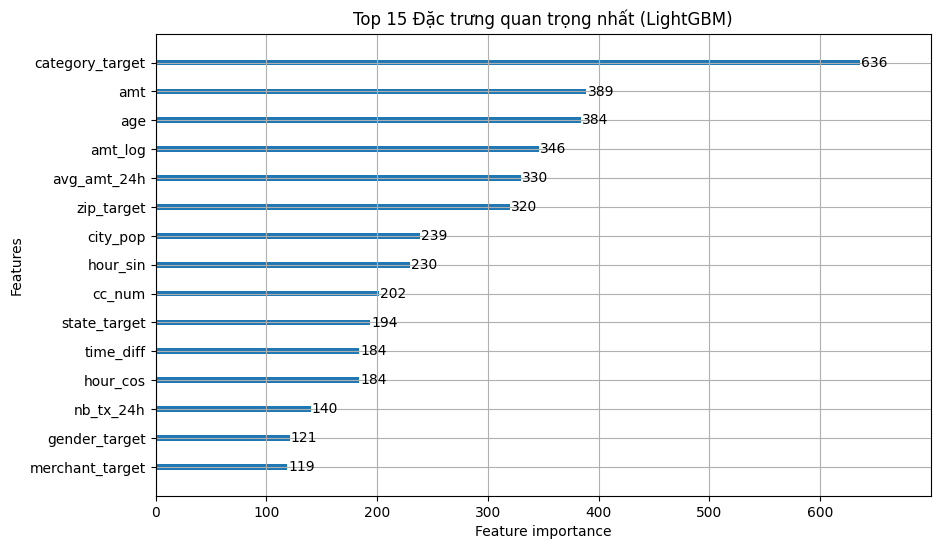

In [18]:
import lightgbm as lgb
from sklearn.metrics import precision_recall_curve, classification_report, fbeta_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Chuẩn bị dữ liệu (Tách Features và Target)
X_train_final = train_final.drop(columns=['is_fraud'])
y_train_final = train_final['is_fraud']

X_val_final = val_final.drop(columns=['is_fraud'])
y_val_final = val_final['is_fraud']

X_test_final = test_final.drop(columns=['is_fraud'])
y_test_final = test_final['is_fraud']

# 2. Xử lý Imbalance (Tính tỷ lệ Negative / Positive)
count_neg = y_train_final.value_counts()[0]
count_pos = y_train_final.value_counts()[1]
ratio = count_neg / count_pos
print(f"Tỷ lệ mất cân bằng (Negative/Positive) trên tập Train: {ratio:.2f}")

# 3. Huấn luyện mô hình LightGBM
print("\nĐang huấn luyện mô hình LightGBM trên GPU...")
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=ratio, # Chìa khóa xử lý Imbalance
    device='gpu',           # Tận dụng GPU
    random_state=42,
    verbose=-1
)

# Sử dụng early stopping
model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_val_final, y_val_final)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# 4. Tìm Threshold tối ưu bằng F2-Score trên tập Validation
print("\nĐang tìm Threshold tối ưu trên tập Validation...")
y_val_probs = model.predict_proba(X_val_final)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_final, y_val_probs)

# Tính F2-score cho từng ngưỡng
f2_scores = []
for p, r in zip(precisions, recalls):
    if (4 * p + r) == 0:
        f2_scores.append(0)
    else:
        f2_scores.append((5 * p * r) / (4 * p + r))

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
print(f"Threshold tối ưu nhất (F2-Score): {best_threshold:.4f}")

# 5. Đánh giá cuối cùng trên tập TEST
print("\n--- KẾT QUẢ TRÊN TẬP TEST ---")
y_test_probs = model.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print(classification_report(y_test_final, y_test_pred, digits=4))

final_f2 = fbeta_score(y_test_final, y_test_pred, beta=2)
print(f"F2-Score cuối cùng trên tập Test: {final_f2:.4f}")

# 6. Trực quan hóa Feature Importance
lgb.plot_importance(model, max_num_features=15, figsize=(10, 6),
                    title='Top 15 Đặc trưng quan trọng nhất (LightGBM)',
                    importance_type='split')
plt.show()

In [19]:

save_path = '/content/drive/MyDrive/fraud detection banking dataset/Clean Data/'

train_final.to_csv(os.path.join(save_path, 'train_final.csv'), index=False)
val_final.to_csv(os.path.join(save_path, 'val_final.csv'), index=False)
test_final.to_csv(os.path.join(save_path, 'test_final.csv'), index=False)
